In [1]:
print("hello")

hello


In [2]:
import torch.nn as nn

nn.Linear(10, 5)

Linear(in_features=10, out_features=5, bias=True)

In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(in_features=3, out_features=4, bias=True)
        self.fc1_act = nn.ReLU()
        self.fc2 = nn.Linear(in_features=4, out_features=3, bias=True)
        self.fc2_act = nn.ReLU()
        self.fc3 = nn.Linear(in_features=3, out_features=1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.fc1_act(x)
        x = self.fc2(x)
        x = self.fc2_act(x)
        x = self.fc3(x)
        return x
    
model = Net()
model

Net(
  (fc1): Linear(in_features=3, out_features=4, bias=True)
  (fc1_act): ReLU()
  (fc2): Linear(in_features=4, out_features=3, bias=True)
  (fc2_act): ReLU()
  (fc3): Linear(in_features=3, out_features=1, bias=True)
)

In [4]:
import torch

In [5]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.4790, -0.0834, -0.4236],
         [-0.2081, -0.4569,  0.4369],
         [ 0.3730,  0.4338, -0.1464],
         [ 0.5106,  0.1298,  0.2648]], requires_grad=True),
 Parameter containing:
 tensor([0.3166, 0.1658, 0.4860, 0.0204], requires_grad=True),
 Parameter containing:
 tensor([[-0.4875,  0.4464, -0.4317,  0.0943],
         [ 0.3041,  0.4211, -0.3073,  0.0831],
         [ 0.0112, -0.2156,  0.1101, -0.4215]], requires_grad=True),
 Parameter containing:
 tensor([ 0.0583, -0.0459, -0.3759], requires_grad=True),
 Parameter containing:
 tensor([[ 0.4433,  0.3588, -0.0697]], requires_grad=True),
 Parameter containing:
 tensor([0.0263], requires_grad=True)]

In [6]:
X = torch.randn(100, 1)
X *= 10
X.shape

torch.Size([100, 1])

In [7]:
y = X+torch.randn(100, 1)
y.shape

torch.Size([100, 1])

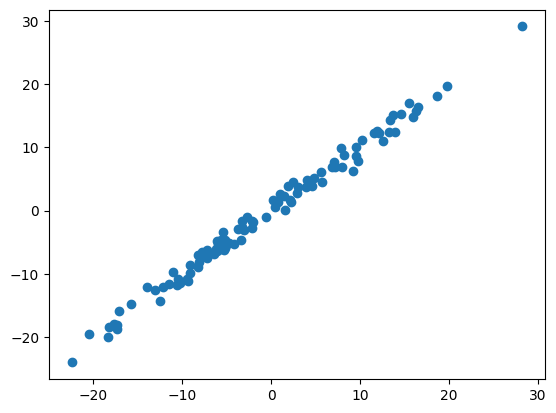

In [8]:
# X, y 시각화
import matplotlib.pyplot as plt
plt.scatter(X, y)


In [9]:
import torch.nn as nn
import torch
# 선형 회귀 모델은 입력과 출력이 모두 1차원이므로 in_features=1, out_features=1로 설정
class LRModel(nn.Module): # Linear Regression Model
    def __init__(self): # constructor
        super(LRModel, self).__init__() # 부모 클래스의 생성자 호출
        self.fc1 = nn.Linear(1,4)
        self.fc1_act = nn.ReLU() # ReLU를 추가하여 모델의 표현력을 높일 수 있습니다.
        self.fc2 = nn.Linear(4,3)
        self.fc2_act = nn.ReLU() 
        self.fc3 = nn.Linear(3,1) 
    
    def forward(self, x): 
        x = self.fc1(x) 
        x = self.fc1_act(x)
        x = self.fc2(x)
        x = self.fc2_act(x)
        x = self.fc3(x)
        return x
    # forward 메서드는 모델의 순전파를 정의하는 메서드입니다. 입력 x를 받아서 모델의 출력을 반환합니다.
    # 선형 회귀 모델에서는 입력 x에 대해 선형 변환을 수행하는 fc1 레이어를 적용합니다. 
    ## 이 레이어는 입력 x에 가중치와 편향을 곱하여 선형 변환을 수행합니다.
    # 모델의 출력은 선형 변환의 결과입니다. 선형 회귀 모델에서는 활성화 함수가 필요하지 않으므로, 
    ## fc1 레이어의 출력이 최종 모델의 출력이 됩니다.
    
model = LRModel()
model

LRModel(
  (fc1): Linear(in_features=1, out_features=4, bias=True)
  (fc1_act): ReLU()
  (fc2): Linear(in_features=4, out_features=3, bias=True)
  (fc2_act): ReLU()
  (fc3): Linear(in_features=3, out_features=1, bias=True)
)

In [10]:
print(list(model.parameters()))

[Parameter containing:
tensor([[ 0.6237],
        [-0.2882],
        [ 0.9552],
        [ 0.1347]], requires_grad=True), Parameter containing:
tensor([-0.7443,  0.1531, -0.7084, -0.6801], requires_grad=True), Parameter containing:
tensor([[ 0.2971,  0.3875,  0.3185,  0.1536],
        [ 0.0369,  0.0522, -0.0352,  0.0781],
        [ 0.0937,  0.0378, -0.0687, -0.4446]], requires_grad=True), Parameter containing:
tensor([-0.1141, -0.2274, -0.1220], requires_grad=True), Parameter containing:
tensor([[0.2900, 0.3849, 0.4990]], requires_grad=True), Parameter containing:
tensor([-0.4935], requires_grad=True)]


In [11]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=1e-2) # 모델의 매개변수와 학습률을 지정하여 Adam 옵티마이저를 생성합니다.

criterion = nn.MSELoss() # 손실 함수로 평균 제곱 오차(MSE)를 사용합니다.
criterion


MSELoss()

In [12]:
# hyperparameters : epochs, learning rate, batch size
loss_list = []

epochs = 5000
for epoch in range(epochs):
    model.train() # 모델을 학습 모드로 설정합니다.
    optimizer.zero_grad() # 옵티마이저의 기울기를 초기화합니다.
    outputs = model(X) # 모델에 입력 X를 전달하여 예측값을 계산합니다.
    loss = criterion(outputs, y) # 예측값과 실제값 y 사이의 손실을 계산합니다.
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}") # 현재 에포크와 손실 값을 출력합니다.
    loss_list.append(loss.item()) # 손실 값을 리스트에 저장합니다. - loss.item()는 텐서에서 스칼라 값을 추출하는 메서드입니다.
    loss.backward() # 손실에 대한 모델의 매개변수의 기울기를 계산합니다. - 미분
    optimizer.step() # 옵티마이저가 모델의 매개변수를 업데이트하도록 합니다.

Epoch 1/5000, Loss: 99.4614
Epoch 2/5000, Loss: 98.0368
Epoch 3/5000, Loss: 96.7228
Epoch 4/5000, Loss: 95.3847
Epoch 5/5000, Loss: 93.9895
Epoch 6/5000, Loss: 92.5383
Epoch 7/5000, Loss: 91.0322
Epoch 8/5000, Loss: 89.4729
Epoch 9/5000, Loss: 87.8622
Epoch 10/5000, Loss: 86.2023
Epoch 11/5000, Loss: 84.4972
Epoch 12/5000, Loss: 82.7498
Epoch 13/5000, Loss: 80.9640
Epoch 14/5000, Loss: 79.1494
Epoch 15/5000, Loss: 77.3147
Epoch 16/5000, Loss: 75.4629
Epoch 17/5000, Loss: 73.5452
Epoch 18/5000, Loss: 71.4896
Epoch 19/5000, Loss: 69.3713
Epoch 20/5000, Loss: 67.2371
Epoch 21/5000, Loss: 65.1145
Epoch 22/5000, Loss: 63.0655
Epoch 23/5000, Loss: 61.1016
Epoch 24/5000, Loss: 59.2470
Epoch 25/5000, Loss: 57.5254
Epoch 26/5000, Loss: 55.9732
Epoch 27/5000, Loss: 54.6263
Epoch 28/5000, Loss: 53.5156
Epoch 29/5000, Loss: 52.6668
Epoch 30/5000, Loss: 52.0938
Epoch 31/5000, Loss: 51.7934
Epoch 32/5000, Loss: 51.7412
Epoch 33/5000, Loss: 51.8873
Epoch 34/5000, Loss: 52.1561
Epoch 35/5000, Loss: 52

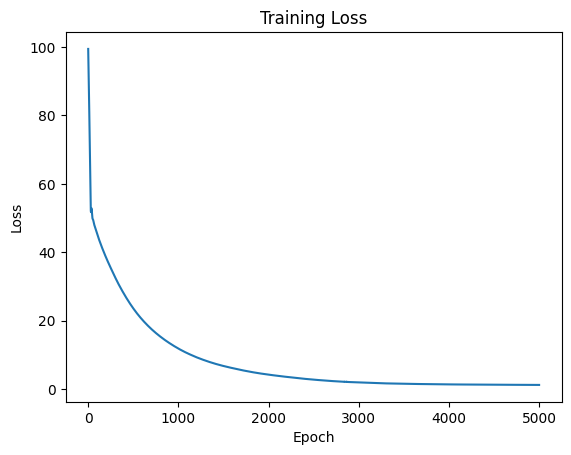

In [13]:
# loss_list 시각화
plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()
